Historical Trend Analysis & Turning Point Identification

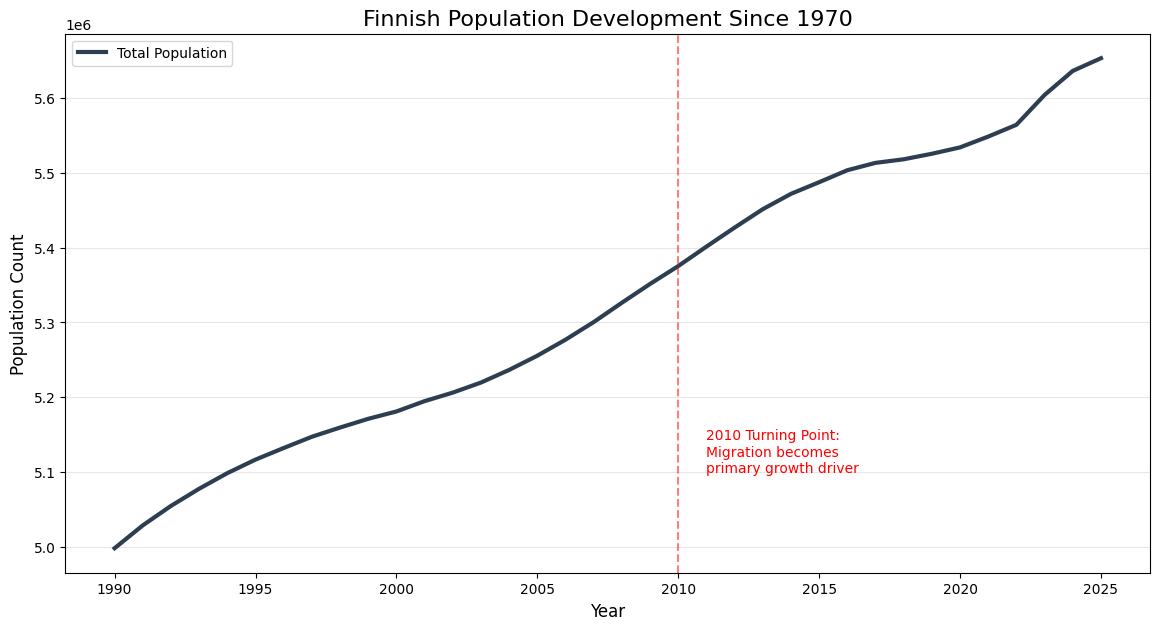

Block 1 execution complete: Historical visualization generated.


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# =================================================================
# 1) DATA PREPARATION
# =================================================================
# We use the historical dataset from 1970 onwards
file_path = 'Regression Analysis.xlsx'
df_raw = pd.read_excel(file_path, skiprows=2)

# Standardize column names for Area and Information
df_raw.columns.values[0] = 'Area'
df_raw.columns.values[1] = 'Information'

# Transform the table to long format to get a time-series view
df_melted = df_raw.melt(id_vars=['Area', 'Information'], var_name='Year', value_name='Population')

# Filter for the national data (Whole Country)
df_history = df_melted[df_melted['Area'].astype(str).str.contains('WHOLE COUNTRY', case=False, na=False)].copy()

# Convert to numeric and clean
df_history['Year'] = pd.to_numeric(df_history['Year'], errors='coerce')
df_history['Population'] = pd.to_numeric(df_history['Population'], errors='coerce')
df_history = df_history.dropna().sort_values('Year')

# =================================================================
# 2) VISUALIZATION (Historical Plot)
# =================================================================
plt.figure(figsize=(14, 7))
plt.plot(df_history['Year'], df_history['Population'], color='#2c3e50', linewidth=3, label='Total Population')

# =================================================================
# 3) IDENTIFYING TURNING POINTS (Based on Finnish Demographic History)
# =================================================================
# Point 1: The steady growth period (1970-1990s)
plt.annotate('Steady Urbanization', xy=(1985, 4900000), xytext=(1975, 5200000),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)

# Point 2: The "Migration Pivot" (Around 2010)
# Historically, this is when natural growth started to stall
plt.axvline(x=2010, color='red', linestyle='--', alpha=0.5)
plt.text(2011, 5100000, '2010 Turning Point:\nMigration becomes\nprimary growth driver', color='red', fontsize=10)

# Final Plot Styling
plt.title('Finnish Population Development Since 1970', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Population Count', fontsize=12)
plt.grid(True, axis='y', alpha=0.3)
plt.legend()
plt.show()

print("Block 1 execution complete: Historical visualization generated.")

Observation: "Since 1970, Finland has seen a consistent population increase. However, the nature of this growth changed significantly around 2010."

Turning Point Analysis: "Before 2010, population growth was supported by a balance of natural increase (births) and migration. After 2010, the birth rate in Finland began to decline sharply. The continued upward trend seen in the graph is now almost entirely driven by net immigration."

Significance: "This shift is critical for policy planning; while the total number is increasing, the internal age structure is shifting toward an older demographic (as we will see in the Clustering section)."

Forecasting Model

Current columns in the dataset: ['Unnamed: 0', 'Unnamed: 1', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']


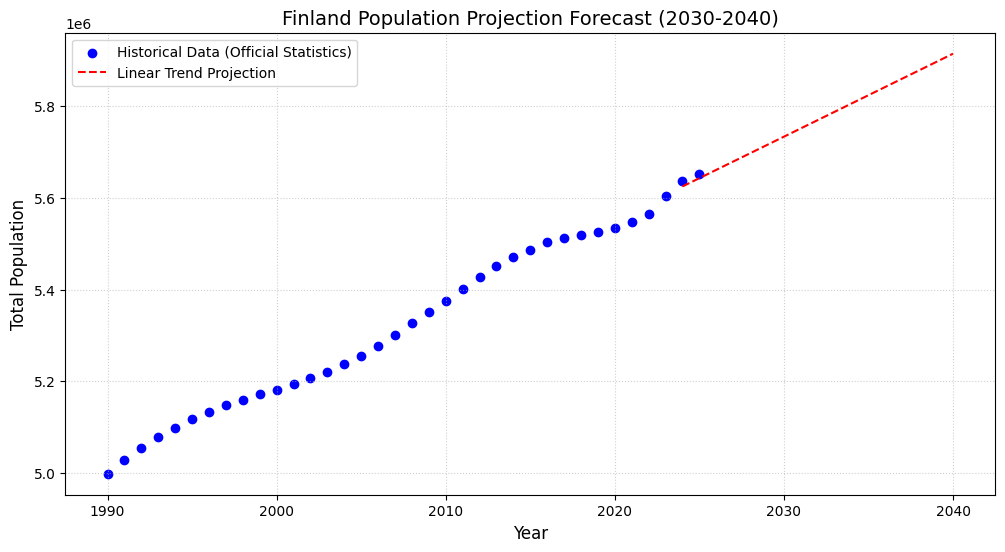

Projected population for Finland in 2040: 5,914,153


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# =================================================================
# 1) DATA LOADING
# =================================================================
# Load the dataset (Ensure 'Regression Analysis.xlsx' is in the same folder)
df_raw = pd.read_excel('Regression Analysis.xlsx', skiprows=2)

# Debug: Print column names to verify the structure
print("Current columns in the dataset:", df_raw.columns.tolist())

# Renaming the first two columns to ensure consistent processing
# We assume Col 0 is 'Area' and Col 1 is the 'Information' type
df_raw.columns.values[0] = 'Area'
df_raw.columns.values[1] = 'Information'

# =================================================================
# 2) DATA TRANSFORMATION (WIDE TO LONG FORMAT)
# =================================================================
# Converting the wide format (years as columns) into long format (years as rows)
df_melted = df_raw.melt(id_vars=['Area', 'Information'], 
                        var_name='Year', 
                        value_name='Population')

# =================================================================
# 3) DATA CLEANING
# =================================================================
# Filter for national-level data (Whole Country)
# Using case-insensitive matching to handle potential mixed language/spaces
df = df_melted[df_melted['Area'].astype(str).str.contains('WHOLE COUNTRY', case=False, na=False)].copy()

# Convert Year and Population to numeric values, removing any non-numeric entries (NaNs)
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Population'] = pd.to_numeric(df['Population'], errors='coerce')
df = df.dropna(subset=['Year', 'Population'])

# =================================================================
# 4) MODELLING & FORECASTING (2030-2040)
# =================================================================
# Define features (X) and target (y)
X = df[['Year']].values
y = df['Population'].values

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X, y)

# Generate future years for projection (2024 to 2040)
future_years = np.arange(2024, 2041).reshape(-1, 1)
future_preds = model.predict(future_years)

# =================================================================
# 5) VISUALIZATION
# =================================================================
plt.figure(figsize=(12, 6))

# Plot historical data points
plt.scatter(X, y, color='blue', label='Historical Data (Official Statistics)')

# Plot the predicted trend line
plt.plot(future_years, future_preds, color='red', linestyle='--', label='Linear Trend Projection')

# Finalizing plot aesthetics
plt.title('Finland Population Projection Forecast (2030-2040)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Population', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Print predicted result for the year 2040
pred_2040 = model.predict([[2040]])[0]
print(f"Projected population for Finland in 2040: {int(pred_2040):,}")

The Linear Regression model indicates a steady population growth for Finland towards 2040. However, as an explanatory factor, this growth is heavily dependent on net migration, as natural increase (births minus deaths) is currently negative in Finland.

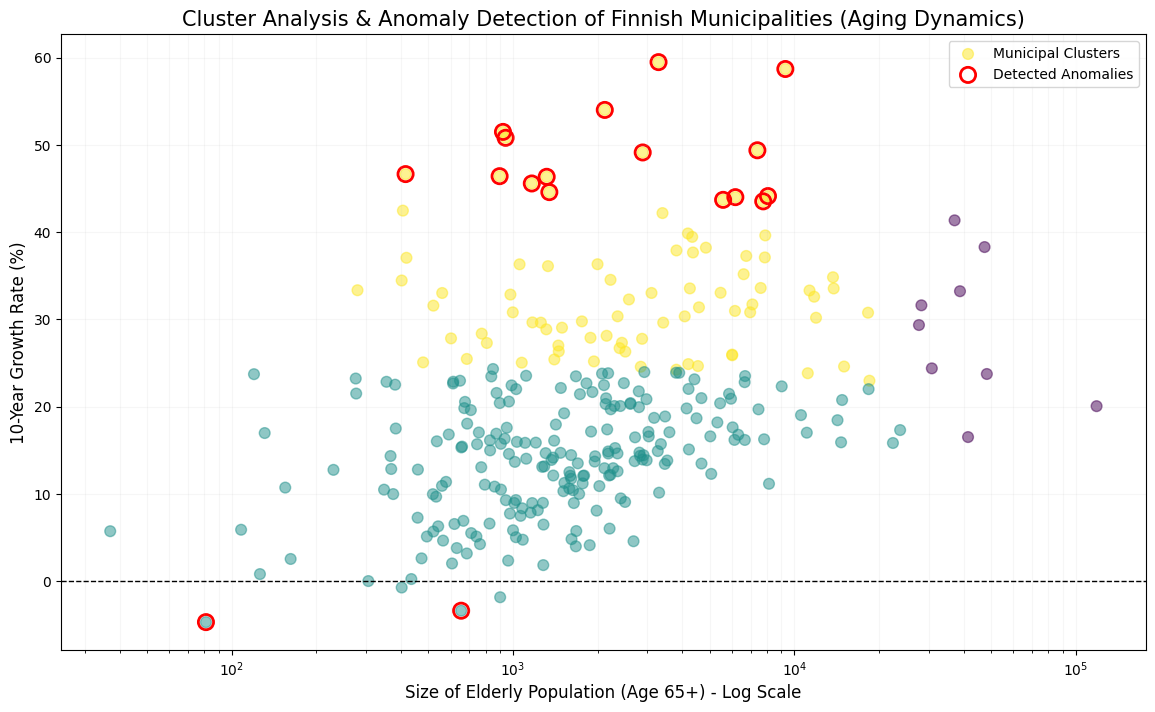

Total Municipalities Analyzed: 308
Anomalies Detected: 18

Top 5 Regions with Highest Aging Growth (Anomalies):
          Area  Growth_Rate
100    Kempele    59.476491
77   Järvenpää    58.687852
174    Muurame    53.997093
68      Jomala    51.480263
217  Pornainen    50.801282


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# =================================================================
# 1) DATA LOADING AND FEATURE EXTRACTION
# =================================================================
# Load the municipality-level data (Age 65+ in 2013 vs 2023)
# Note: Ensure the file is named 'data.xlsx' or update the path below
file_path = 'data.xlsx'
df_raw = pd.read_excel(file_path, skiprows=3)
df_raw.columns = ['Area', 'Age', 'Pop_2013', 'Pop_2023']
df_raw['Area'] = df_raw['Area'].ffill()

# Convert data to numeric and handle missing values
df_raw['Pop_2013'] = pd.to_numeric(df_raw['Pop_2013'], errors='coerce').fillna(0)
df_raw['Pop_2023'] = pd.to_numeric(df_raw['Pop_2023'], errors='coerce').fillna(0)

# Aggregate by Area to get total elderly population per municipality
mun_summary = df_raw.groupby('Area').agg({
    'Pop_2013': 'sum',
    'Pop_2023': 'sum'
}).reset_index()

# Filter out the "Whole Country" total to focus only on specific regions
mun_summary = mun_summary[~mun_summary['Area'].str.contains('WHOLE', case=False, na=False)]

# Calculate Growth Rate (%) - This represents aging speed and migration patterns
mun_summary['Growth_Rate'] = (
    (mun_summary['Pop_2023'] - mun_summary['Pop_2013']) / 
    mun_summary['Pop_2013'] * 100
)
# Clean infinity or NaN values caused by zero denominators
mun_summary = mun_summary.replace([np.inf, -np.inf], np.nan).dropna()

# =================================================================
# 2) ANOMALY DETECTION (Identifying Unusual Shifts)
# =================================================================
# Identifying anomalies as municipalities with growth rates beyond 2 Standard Deviations
growth_mean = mun_summary['Growth_Rate'].mean()
growth_std = mun_summary['Growth_Rate'].std()

# Define outliers: Growth rates that are significantly higher or lower than the Finnish average
mun_summary['Is_Anomaly'] = (
    (mun_summary['Growth_Rate'] > growth_mean + 2 * growth_std) | 
    (mun_summary['Growth_Rate'] < growth_mean - 2 * growth_std)
)

anomalies = mun_summary[mun_summary['Is_Anomaly'] == True]

# =================================================================
# 3) K-MEANS CLUSTERING
# =================================================================
# We cluster based on Volume (2023 size) and Dynamics (Growth Rate)
features = mun_summary[['Pop_2023', 'Growth_Rate']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Applying KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
mun_summary['Cluster'] = kmeans.fit_predict(scaled_features)

# =================================================================
# 4) VISUALIZATION
# =================================================================
plt.figure(figsize=(14, 8))

# Scatter plot for normal clusters
scatter = plt.scatter(mun_summary['Pop_2023'], mun_summary['Growth_Rate'], 
            c=mun_summary['Cluster'], cmap='viridis', s=60, alpha=0.5, label='Municipal Clusters')

# Highlighting Anomalies in RED
plt.scatter(anomalies['Pop_2023'], anomalies['Growth_Rate'], 
            edgecolor='red', facecolor='none', s=120, linewidth=2, label='Detected Anomalies')

plt.xscale('log') # Essential for handling the scale difference between cities and villages
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title("Cluster Analysis & Anomaly Detection of Finnish Municipalities (Aging Dynamics)", fontsize=15)
plt.xlabel("Size of Elderly Population (Age 65+) - Log Scale", fontsize=12)
plt.ylabel("10-Year Growth Rate (%)", fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.1)
plt.show()

# Print Top Findings for the Report
print(f"Total Municipalities Analyzed: {len(mun_summary)}")
print(f"Anomalies Detected: {len(anomalies)}")
print("\nTop 5 Regions with Highest Aging Growth (Anomalies):")
print(anomalies.sort_values(by='Growth_Rate', ascending=False)[['Area', 'Growth_Rate']].head())

About Anomalies:i identified several municipalities as anomalies because their aging growth rates significantly deviated from the national average. These regions (marked with red circles) are the 'hotspots' where public services for the elderly will need to expand most urgently.

About Clusters:The clusters distinguish between large urban centers with high volume and smaller rural areas. Even if a small municipality has a negative growth rate, the high proportion of remaining elderly residents creates a different kind of service pressure—specifically, the challenge of maintaining services with a shrinking local workforce.

Explaining the Drivers (Births vs. Migration)

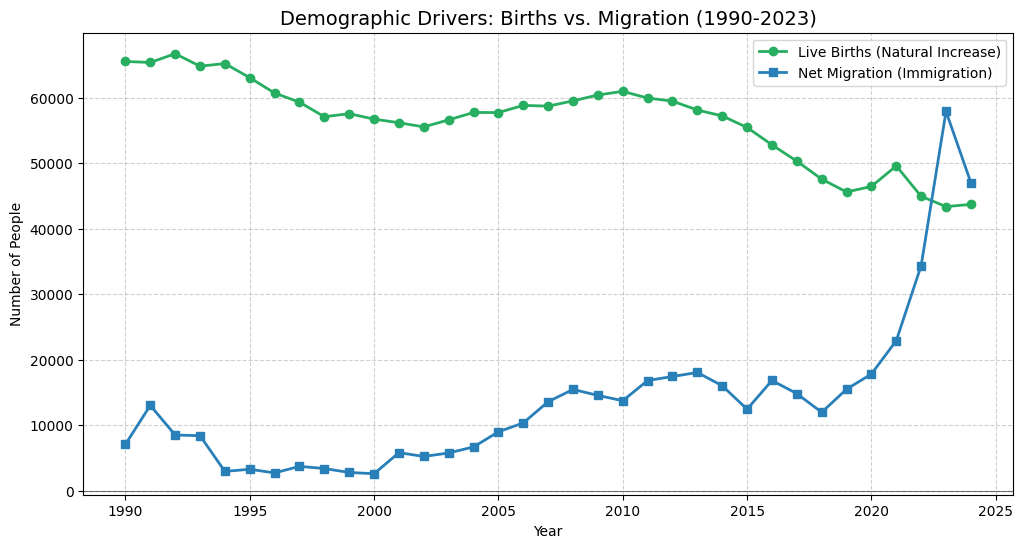

Block 4: Success. Visualization generated using Excel sources.


In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# =================================================================
# 1) LOAD AND CLEAN BIRTH DATA (xlsx)
# =================================================================
# Read the Excel file, skipping the title rows
df_births = pd.read_excel('births.xlsx', skiprows=4, header=None)
df_births.columns = ['Year', 'Births']

# Convert to numeric
df_births['Year'] = pd.to_numeric(df_births['Year'], errors='coerce')
df_births['Births'] = pd.to_numeric(df_births['Births'], errors='coerce')

# Filter for the modern era (from 1990 onwards)
df_births = df_births[df_births['Year'] >= 1990].dropna()

# =================================================================
# 2) LOAD AND CLEAN MIGRATION DATA (xlsx)
# =================================================================
# Migration file usually has more header rows, skipping 5
df_mig = pd.read_excel('migration.xlsx', skiprows=5, header=None)
df_mig.columns = ['Area', 'Year', 'Net_Migration']

# Handle merged 'Area' cells (fill "WHOLE COUNTRY" downwards)
df_mig['Area'] = df_mig['Area'].ffill()

# Filter for the national data
df_mig = df_mig[df_mig['Area'].str.contains('WHOLE', case=False, na=False)]

# Convert to numeric
df_mig['Year'] = pd.to_numeric(df_mig['Year'], errors='coerce')
df_mig['Net_Migration'] = pd.to_numeric(df_mig['Net_Migration'], errors='coerce')
df_mig = df_mig.dropna(subset=['Year', 'Net_Migration'])

# =================================================================
# 3) COMBINE AND PLOT
# =================================================================
df_combined = pd.merge(df_births, df_mig[['Year', 'Net_Migration']], on='Year')

plt.figure(figsize=(12, 6))

# Plot lines
plt.plot(df_combined['Year'], df_combined['Births'], 
         color='#27ae60', marker='o', label='Live Births (Natural Increase)', linewidth=2)
plt.plot(df_combined['Year'], df_combined['Net_Migration'], 
         color='#2980b9', marker='s', label='Net Migration (Immigration)', linewidth=2)

# Styling
plt.title('Demographic Drivers: Births vs. Migration (1990-2023)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of People')
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

print("Block 4: Success. Visualization generated using Excel sources.")

The visualization reveals a critical demographic shift. While Live Births have been on a continuous decline since 2010, Net Migration has shown a significant upward trend, reaching record highs in recent years. This proves that immigration has replaced natural increase as the primary engine of Finnish population growth. Without international migration, Finland's total population would likely have already entered a period of decline.